# 02 · Exploratory Data Analysis
Understanding channel mix, revenue distribution, seasonality, and customer composition.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from src.visualization import PALETTE
sns.set_theme(style='whitegrid')

campaigns = pd.read_csv('../data/processed/campaigns_clean.csv', parse_dates=['start_date','end_date'])
customers = pd.read_csv('../data/processed/customers_clean.csv', parse_dates=['signup_date','purchase_date'])
transactions = pd.read_csv('../data/processed/transactions_clean.csv', parse_dates=['order_date'])
campaigns.shape, customers.shape, transactions.shape

((5200, 18), (5400, 13), (21500, 9))

## Channel Mix — Spend vs Revenue

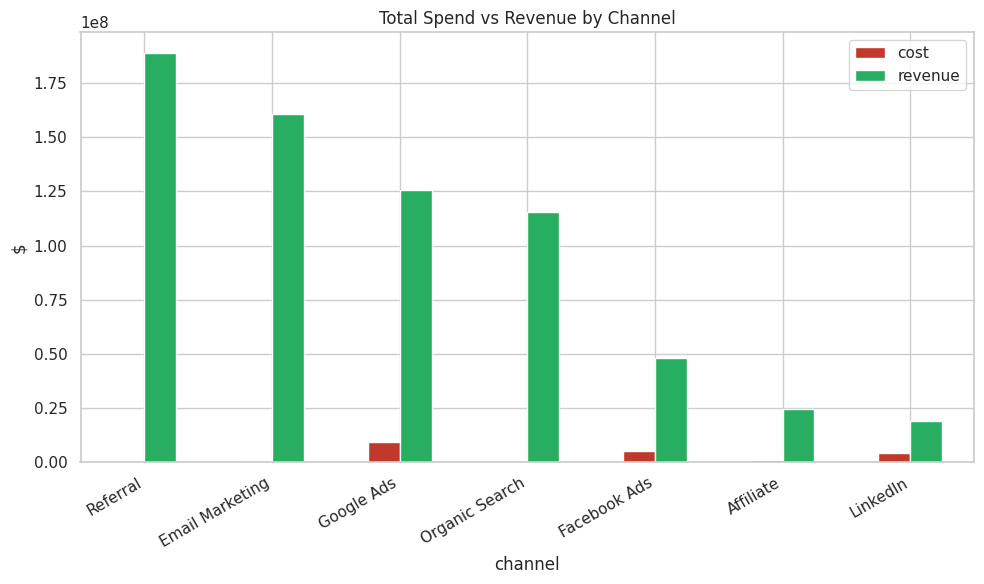

In [2]:
agg = campaigns.groupby('channel')[['cost','revenue']].sum().sort_values('revenue', ascending=False)
agg.plot(kind='bar', figsize=(10,6), color=['#c0392b','#27ae60'])
plt.title('Total Spend vs Revenue by Channel'); plt.ylabel('$'); plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

## Revenue Distribution

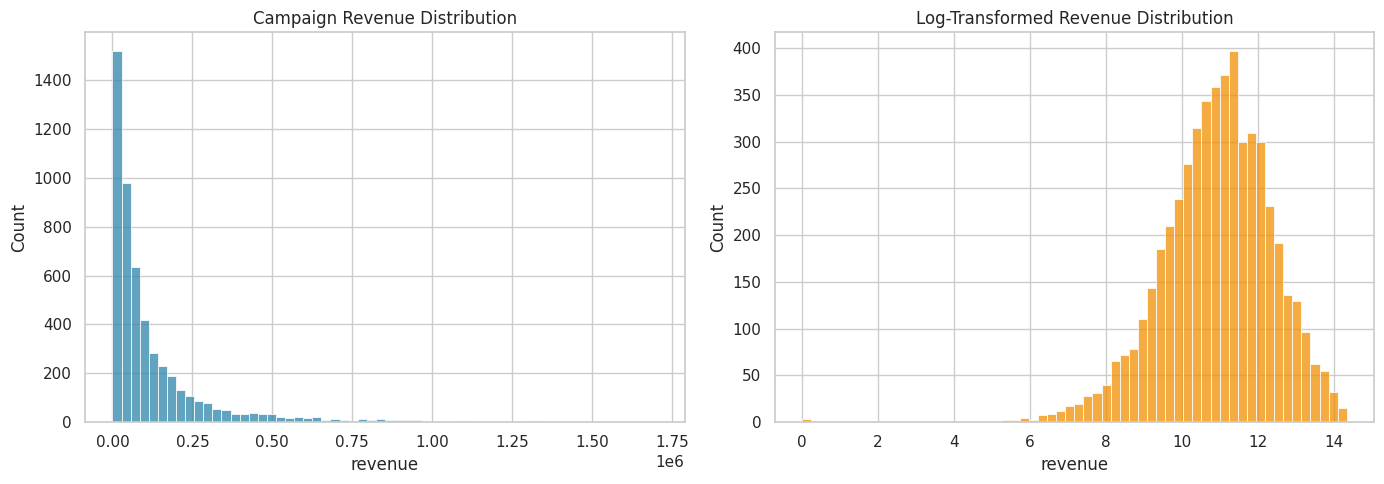

In [3]:
fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.histplot(campaigns['revenue'], bins=60, ax=ax[0], color='#2E86AB')
ax[0].set_title('Campaign Revenue Distribution')
sns.histplot(np.log1p(campaigns['revenue']), bins=60, ax=ax[1], color='#F18F01')
ax[1].set_title('Log-Transformed Revenue Distribution')
plt.tight_layout(); plt.show()

## Monthly Seasonality

In [4]:
campaigns['month'] = campaigns['start_date'].dt.to_period('M').astype(str)
monthly = campaigns.groupby('month')['revenue'].sum().reset_index()
fig = px.line(monthly, x='month', y='revenue', title='Total Monthly Revenue', markers=True)
fig.show()

## Customer Composition

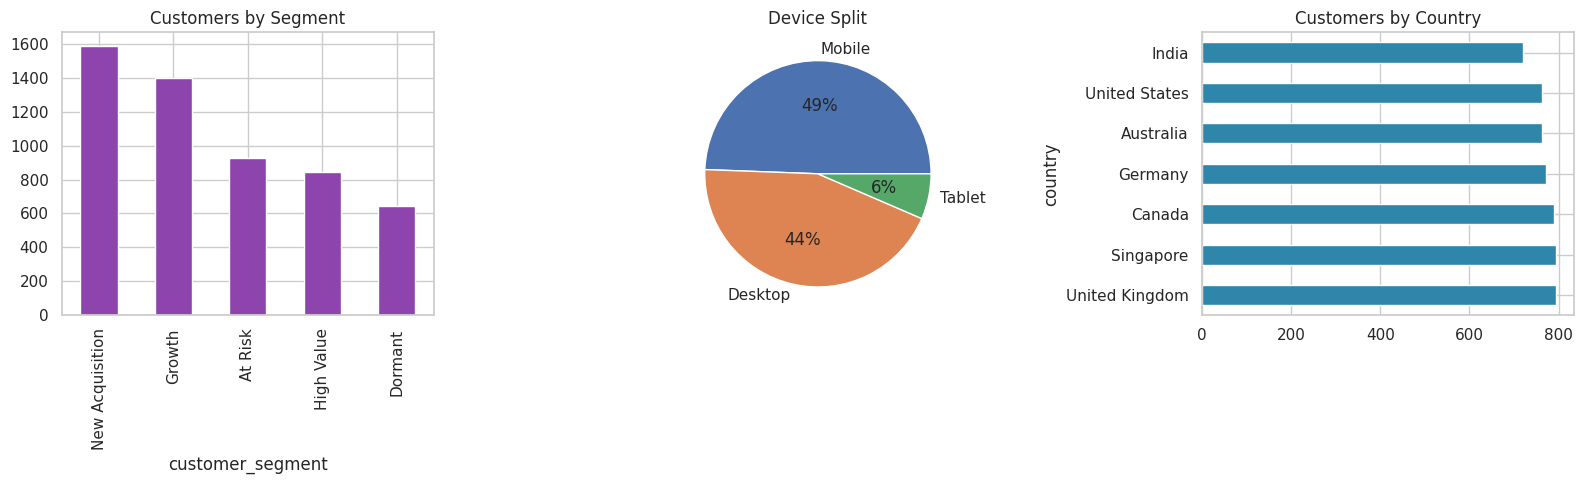

In [5]:
fig, axes = plt.subplots(1,3, figsize=(16,5))
customers['customer_segment'].value_counts().plot(kind='bar', ax=axes[0], color='#8E44AD')
axes[0].set_title('Customers by Segment')
customers['device'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.0f%%')
axes[1].set_title('Device Split'); axes[1].set_ylabel('')
customers['country'].value_counts().plot(kind='barh', ax=axes[2], color='#2E86AB')
axes[2].set_title('Customers by Country')
plt.tight_layout(); plt.show()

## Key Observations
- Google Ads and Facebook Ads dominate spend but organic/referral channels deliver disproportionately high ROI.
- Revenue is right-skewed, as expected for transactional marketing data — log-transform improves normality for later statistical tests.
- Customer segments are led by *New Acquisition* and *Growth*, consistent with an actively-scaling SaaS acquisition funnel.